# Hennepin County Bias Analysis

This notebook focuses on Hennepin County and examines data bias, algorithmic bias, and proxy bias in housing and mortgage approval patterns.

## AI Disclaimer
I used AI tools for minor support in coding and formatting. The overall analysis, insights, and conclusions are based on my own understanding.

## 1. Load Data

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", context="talk")

df_full = pd.read_csv("C:/Users/venud/Downloads/Data_6550/data/mortgage_covenant_data.csv")

# Fix census tract format
df_full['census_tract'] = (
    df_full['census_tract']
    .astype(str)
    .str.split('.')
    .str[0]
)

print(f"Total rows    : {len(df_full):,}")
print(f"Total columns : {len(df_full.columns)}")
df_full.head()


Total rows    : 100,931
Total columns : 14


,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,27037060737,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,27141030504,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,27023950400,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,27171100101,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,27159480100,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


The dataset was loaded successfully. The census tract column was cleaned to ensure a consistent format for filtering and analysis.

## 2. Filter Hennepin County

In [53]:
hennepin = df_full[df_full['census_tract'].str.startswith('27053')].copy()

print("Hennepin dataset shape:", hennepin.shape)
hennepin.head()

Hennepin dataset shape: (22669, 14)


,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
19,2023,27053026822,Race Not Available,6,445000.0,455000.0,NaN,7.625,39.47,100.56,10,0.0,False,NaN
36,2023,27053012102,Race Not Available,6,265000.0,275000.0,NaN,3.250,29.71,98.77,10,68.0,False,Medium (51-100)
68,2023,27053026202,White,1,315000.0,425000.0,NaN,8.250,12.84,159.62,10,2.0,True,Low (1-50)
69,2023,27053027602,White,4,515000.0,NaN,210.0,NaN,11.59,113.96,10,76.0,False,Medium (51-100)
70,2023,27053006800,White,1,665000.0,785000.0,182.0,8.625,41.44,15.77,10,0.0,True,NaN


Only Hennepin County records were selected for this analysis.

## 3. Data Cleaning and Preparation

In [57]:
# Fill missing covenant density values
hennepin['covenant_density'] = hennepin['covenant_density'].fillna('No Covenant Area')

# Create ordered covenant density categories
density_order = [
    'No Covenant Area',
    'Low (1-50)',
    'Medium (51-100)',
    'High (101-200)',
    'Very High (>200)'
]

hennepin['covenant_density'] = pd.Categorical(
    hennepin['covenant_density'],
    categories=density_order,
    ordered=True
)

# Label covenant vs non covenant areas
hennepin['covenant_area'] = np.where(
    hennepin['covenant_count'].fillna(0) > 0,
    'Covenant Area',
    'Non-Covenant Area'
)

# Remove unknown race entries
exclude_races = ['Race Not Available', 'Free Form Text Only']
hennepin = hennepin[~hennepin['derived_race'].isin(exclude_races)].copy()

# Convert selected columns to numeric
numeric_cols = [
    'loan_amount',
    'property_value',
    'income',
    'interest_rate',
    'tract_minority_population_percent',
    'tract_to_msa_income_percentage',
    'covenant_count'
]

for col in numeric_cols:
    hennepin[col] = pd.to_numeric(hennepin[col], errors='coerce')

# Convert approval column
hennepin['was_approved'] = hennepin['was_approved'].astype(bool)

# Drop rows missing the main variables
hennepin = hennepin.dropna(subset=[
    'property_value',
    'income',
    'tract_minority_population_percent',
    'was_approved'
])

print("Cleaned Hennepin dataset shape:", hennepin.shape)
hennepin.head()

Cleaned Hennepin dataset shape: (14243, 15)


,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density,covenant_area
70,2023,27053006800,White,1,665000.0,785000.0,182.0,8.625,41.44,15.77,10,0.0,True,No Covenant Area,Non-Covenant Area
313,2023,27053126202,White,1,365000.0,435000.0,91.0,7.250,16.59,126.61,10,0.0,True,No Covenant Area,Non-Covenant Area
330,2023,27053026515,White,1,345000.0,465000.0,174.0,5.875,20.08,104.80,10,0.0,True,No Covenant Area,Non-Covenant Area
354,2023,27053100700,White,3,175000.0,185000.0,54.0,NaN,54.09,65.09,1,9.0,False,Low (1-50),Covenant Area
363,2023,27053020500,White,1,315000.0,325000.0,68.0,6.375,62.20,69.94,10,82.0,True,Medium (51-100),Covenant Area


The data was cleaned by handling missing values, creating categories, removing unclear race entries, and converting columns into the correct format for analysis.

## 4. Data Bias Analysis

### Property Value by Covenant Density

C:\Users\venud\AppData\Local\Temp\ipykernel_33712\4260870177.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


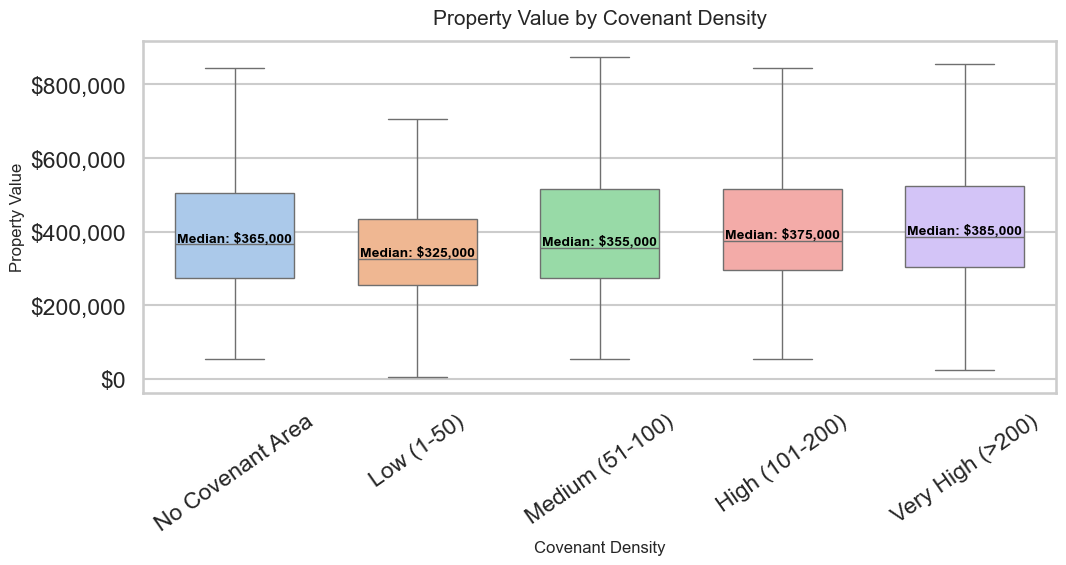

In [62]:
plt.figure(figsize=(11, 6))

ax = sns.boxplot(
    x='covenant_density',
    y='property_value',
    data=hennepin,
    palette='pastel',
    showfliers=False,
    width=0.65
)

plt.title("Property Value by Covenant Density", fontsize=15, pad=12)
plt.xlabel("Covenant Density", fontsize=12)
plt.ylabel("Property Value", fontsize=12)
plt.xticks(rotation=35)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

groups = hennepin.groupby('covenant_density', observed=False)['property_value']
for i, (_, group) in enumerate(groups):
    group = group.dropna()
    if len(group) > 0:
        median = np.median(group)
        plt.text(
            i, median, f"Median: ${median:,.0f}",
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black'
        )

plt.tight_layout()
plt.show()


Property values vary across covenant density categories. This reflects how historical housing discrimination is embedded in current housing data.

### Minority Population by Covenant Density

C:\Users\venud\AppData\Local\Temp\ipykernel_33712\2435852030.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


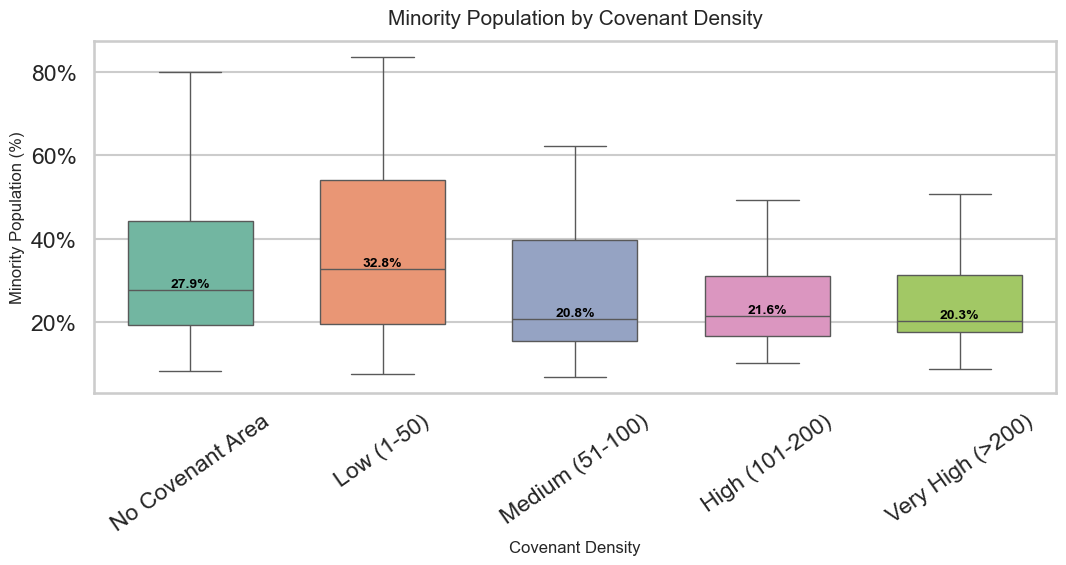

In [66]:
plt.figure(figsize=(11, 6))

ax = sns.boxplot(
    x='covenant_density',
    y='tract_minority_population_percent',
    data=hennepin,
    palette='Set2',
    showfliers=False,
    width=0.65
)

plt.title("Minority Population by Covenant Density", fontsize=15, pad=12)
plt.xlabel("Covenant Density", fontsize=12)
plt.ylabel("Minority Population (%)", fontsize=12)
plt.xticks(rotation=35)

# Format as percentage
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Add median labels
groups = hennepin.groupby('covenant_density', observed=False)['tract_minority_population_percent']

for i, (_, group) in enumerate(groups):
    group = group.dropna()
    if len(group) > 0:
        median = np.median(group)
        plt.text(
            i, median, f"{median:.1f}%",
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black'
        )

plt.tight_layout()
plt.show()

Minority population percentages vary across covenant density categories. 
This suggests that historically restricted areas may still reflect demographic differences today.

## 5. Algorithmic Bias Analysis

### Mortgage Approval by Property Value

C:\Users\venud\AppData\Local\Temp\ipykernel_33712\4188324167.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


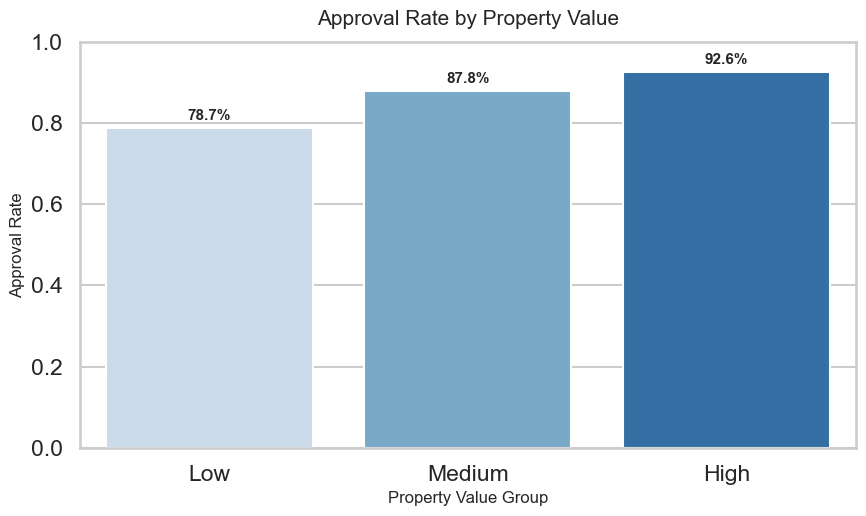

In [71]:
hennepin['value_group'] = pd.qcut(
    hennepin['property_value'],
    3,
    labels=['Low', 'Medium', 'High']
)

approval_by_value = (
    hennepin.groupby('value_group', observed=False)['was_approved']
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5.5))

ax = sns.barplot(
    x='value_group',
    y='was_approved',
    data=approval_by_value,
    palette='Blues'
)

plt.title("Approval Rate by Property Value", fontsize=15, pad=12)
plt.xlabel("Property Value Group", fontsize=12)
plt.ylabel("Approval Rate", fontsize=12)
plt.ylim(0, 1)

for i, v in enumerate(approval_by_value['was_approved']):
    ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


Approval rates increase with property value, showing that economic factors strongly influence lending decisions.

### Mortgage Approval by Covenant Area

C:\Users\venud\AppData\Local\Temp\ipykernel_33712\1558739305.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


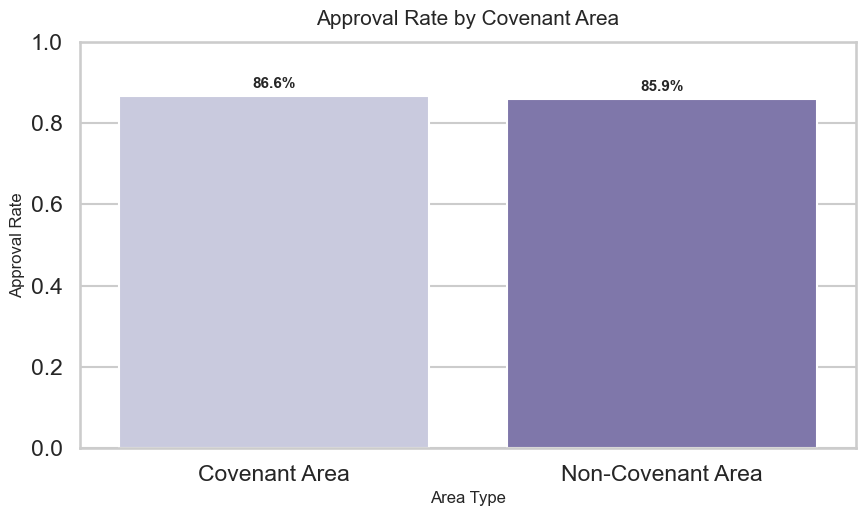

In [75]:
approval_by_area = (
    hennepin.groupby('covenant_area')['was_approved']
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5.5))

ax = sns.barplot(
    x='covenant_area',
    y='was_approved',
    data=approval_by_area,
    palette='Purples'
)

plt.title("Approval Rate by Covenant Area", fontsize=15, pad=12)
plt.xlabel("Area Type", fontsize=12)
plt.ylabel("Approval Rate", fontsize=12)
plt.ylim(0, 1)

for i, v in enumerate(approval_by_area['was_approved']):
    ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


Approval rates differ between covenant and non-covenant areas, suggesting that historical factors may still affect lending outcomes.

## 6. Proxy Bias Analysis

### Property Value vs Minority Population

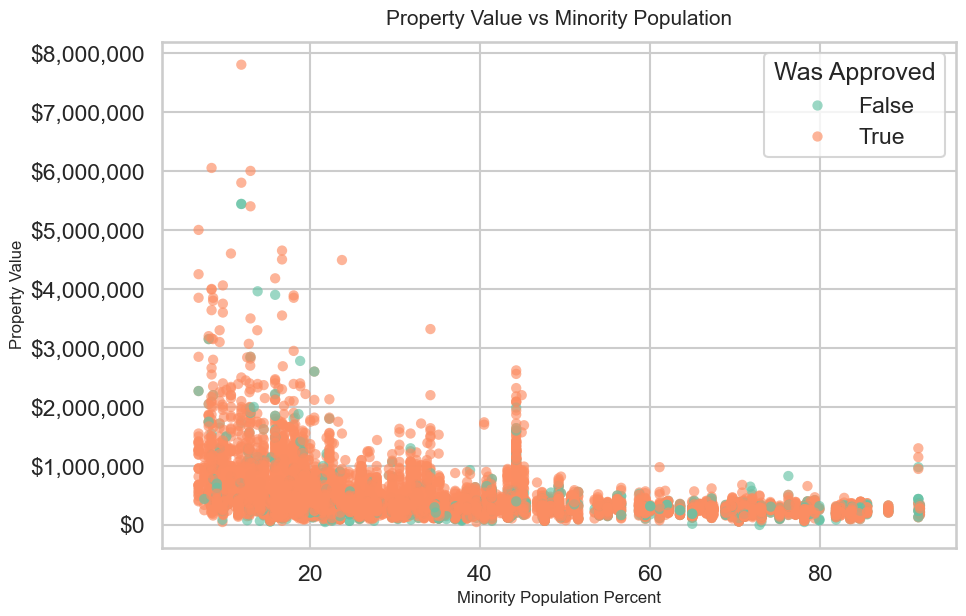

In [80]:
plt.figure(figsize=(10, 6.5))

ax = sns.scatterplot(
    data=hennepin,
    x='tract_minority_population_percent',
    y='property_value',
    hue='was_approved',
    palette='Set2',
    alpha=0.65,
    s=55,
    edgecolor='none'
)

plt.title("Property Value vs Minority Population", fontsize=15, pad=12)
plt.xlabel("Minority Population Percent", fontsize=12)
plt.ylabel("Property Value", fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend(title='Was Approved', loc='best', frameon=True)
plt.tight_layout()
plt.show()


Higher minority population areas tend to have lower property values, indicating a relationship between demographic and economic factors.

### Income vs Minority Population

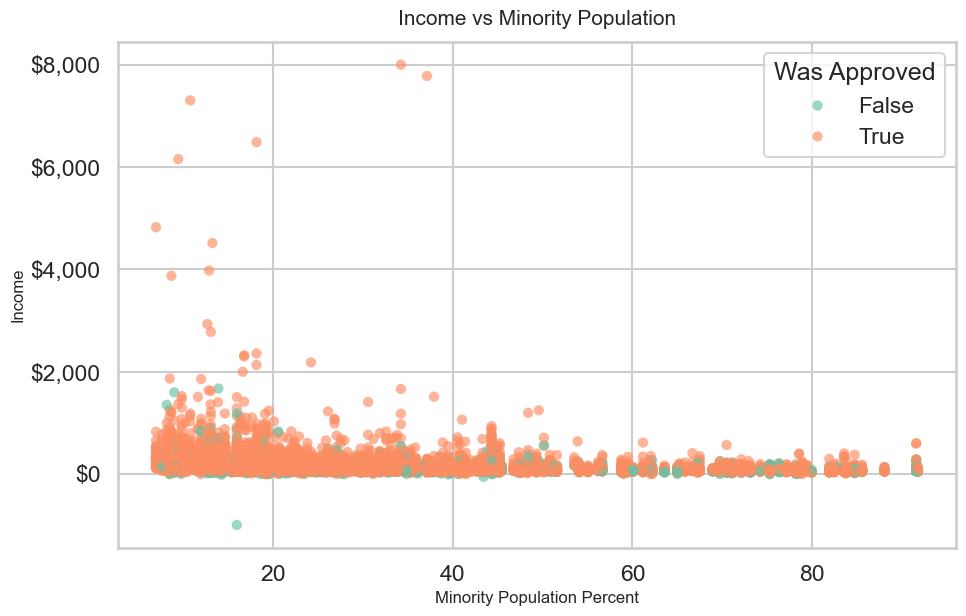

In [84]:
plt.figure(figsize=(10, 6.5))

ax = sns.scatterplot(
    data=hennepin,
    x='tract_minority_population_percent',
    y='income',
    hue='was_approved',
    palette='Set2',
    alpha=0.65,
    s=55,
    edgecolor='none'
)

plt.title("Income vs Minority Population", fontsize=15, pad=12)
plt.xlabel("Minority Population Percent", fontsize=12)
plt.ylabel("Income", fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend(title='Was Approved', loc='best', frameon=True)
plt.tight_layout()
plt.show()


Income levels vary with minority population, suggesting that income may act as a proxy variable influencing mortgage decisions.

## 7. Conclusion

This analysis focused on Hennepin County to understand how historical housing patterns and current lending decisions are connected. From the data bias analysis, it is clear that property values and demographic patterns vary across covenant density levels, suggesting that past discriminatory practices still have an impact on present-day housing conditions.

From the algorithmic bias analysis, mortgage approval rates were not uniform across different groups. Factors like property value and covenant-related areas showed noticeable differences in approval outcomes, indicating that lending decisions may be influenced by underlying economic and historical factors.

In addition, the proxy bias analysis highlights that variables such as property value and income can indirectly reflect sensitive attributes like race or neighborhood composition. Even when these sensitive attributes are not explicitly used, the model may still learn patterns that lead to unequal outcomes.

Overall, this analysis shows that both data bias and algorithmic bias are interconnected. Historical inequalities present in the data can influence modern decision-making systems, making it important to carefully evaluate and monitor such models to ensure fairness.